<div align="center">
  <img src="https://github.com/open-mmlab/mmdetection/raw/3.x/resources/mmdet-logo.png" width="600"/>
  <div>&nbsp;</div>
  <div align="center">
    <b><font size="5">OpenMMLab website</font></b>
    <sup>
      <a href="https://openmmlab.com">
        <i><font size="4">HOT</font></i>
      </a>
    </sup>
    &nbsp;&nbsp;&nbsp;&nbsp;
    <b><font size="5">OpenMMLab platform</font></b>
    <sup>
      <a href="https://platform.openmmlab.com">
        <i><font size="4">TRY IT OUT</font></i>
      </a>
    </sup>
  </div>
  <div>&nbsp;</div>

<a href="https://colab.research.google.com/github/open-mmlab/mmdetection/blob/dev-3.x/demo/inference_demo.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

[![PyPI](https://img.shields.io/pypi/v/mmdet)](https://pypi.org/project/mmdet)
[![docs](https://img.shields.io/badge/docs-latest-blue)](https://mmdetection.readthedocs.io/en/latest/)
[![badge](https://github.com/open-mmlab/mmdetection/workflows/build/badge.svg)](https://github.com/open-mmlab/mmdetection/actions)
[![codecov](https://codecov.io/gh/open-mmlab/mmdetection/branch/master/graph/badge.svg)](https://codecov.io/gh/open-mmlab/mmdetection)
[![license](https://img.shields.io/github/license/open-mmlab/mmdetection.svg)](https://github.com/open-mmlab/mmdetection/blob/master/LICENSE)
[![open issues](https://isitmaintained.com/badge/open/open-mmlab/mmdetection.svg)](https://github.com/open-mmlab/mmdetection/issues)
[![issue resolution](https://isitmaintained.com/badge/resolution/open-mmlab/mmdetection.svg)](https://github.com/open-mmlab/mmdetection/issues)

[📘Documentation](https://mmdetection.readthedocs.io/en/3.x/) |
[🛠️Installation](https://mmdetection.readthedocs.io/en/3.x/get_started.html) |
[👀Model Zoo](https://mmdetection.readthedocs.io/en/3.x/model_zoo.html) |
[🆕Update News](https://mmdetection.readthedocs.io/en/3.x/notes/changelog.html) |
[🚀Ongoing Projects](https://github.com/open-mmlab/mmdetection/projects) |
[🤔Reporting Issues](https://github.com/open-mmlab/mmdetection/issues/new/choose)

</div>

<div align="center">
  <a href="https://openmmlab.medium.com/" style="text-decoration:none;">
    <img src="https://user-images.githubusercontent.com/25839884/219255827-67c1a27f-f8c5-46a9-811d-5e57448c61d1.png" width="3%" alt="" /></a>
  <img src="https://user-images.githubusercontent.com/25839884/218346358-56cc8e2f-a2b8-487f-9088-32480cceabcf.png" width="3%" alt="" />
  <a href="https://discord.com/channels/1037617289144569886/1046608014234370059" style="text-decoration:none;">
    <img src="https://user-images.githubusercontent.com/25839884/218347213-c080267f-cbb6-443e-8532-8e1ed9a58ea9.png" width="3%" alt="" /></a>
  <img src="https://user-images.githubusercontent.com/25839884/218346358-56cc8e2f-a2b8-487f-9088-32480cceabcf.png" width="3%" alt="" />
  <a href="https://twitter.com/OpenMMLab" style="text-decoration:none;">
    <img src="https://user-images.githubusercontent.com/25839884/218346637-d30c8a0f-3eba-4699-8131-512fb06d46db.png" width="3%" alt="" /></a>
  <img src="https://user-images.githubusercontent.com/25839884/218346358-56cc8e2f-a2b8-487f-9088-32480cceabcf.png" width="3%" alt="" />
  <a href="https://www.youtube.com/openmmlab" style="text-decoration:none;">
    <img src="https://user-images.githubusercontent.com/25839884/218346691-ceb2116a-465a-40af-8424-9f30d2348ca9.png" width="3%" alt="" /></a>
  <img src="https://user-images.githubusercontent.com/25839884/218346358-56cc8e2f-a2b8-487f-9088-32480cceabcf.png" width="3%" alt="" />
  <a href="https://space.bilibili.com/1293512903" style="text-decoration:none;">
    <img src="https://user-images.githubusercontent.com/25839884/219026751-d7d14cce-a7c9-4e82-9942-8375fca65b99.png" width="3%" alt="" /></a>
  <img src="https://user-images.githubusercontent.com/25839884/218346358-56cc8e2f-a2b8-487f-9088-32480cceabcf.png" width="3%" alt="" />
  <a href="https://www.zhihu.com/people/openmmlab" style="text-decoration:none;">
    <img src="https://user-images.githubusercontent.com/25839884/219026120-ba71e48b-6e94-4bd4-b4e9-b7d175b5e362.png" width="3%" alt="" /></a>
</div>

# Inferencer

In this tutorial, you will learn how to perform inference with a MMDetection `DetInferencer`.

Let's start!

```{note}
The commands in this tutorial are mainly for Colab.
You can click the button above, `Open in Colab`, to run this notebook in Colab.
```

## Install MMDetection

In [3]:
# Check nvcc version
!nvcc -V
# Check GCC version
!gcc --version

"nvcc" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"gcc" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [ ]:
# install dependencies
%pip install -U openmim
!mim install "mmengine>=0.7.0"
!mim install "mmcv>=2.0.0rc4"

# Install mmdetection
!rm -rf mmdetection
!git clone https://github.com/open-mmlab/mmdetection.git -b dev-3.x
%cd mmdetection

%pip install -e .

In [1]:
from mmengine.utils import get_git_hash
from mmengine.utils.dl_utils import collect_env as collect_base_env

import mmdet


def collect_env():
    """Collect the information of the running environments."""
    env_info = collect_base_env()
    env_info['MMDetection'] = f'{mmdet.__version__}+{get_git_hash()[:7]}'
    return env_info


if __name__ == '__main__':
    for name, val in collect_env().items():
        print(f'{name}: {val}')

sys.platform: win32
Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
CUDA available: True
MUSA available: False
numpy_random_seed: 2147483648
GPU 0: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA_HOME: None
MSVC: n/a, reason: fileno
PyTorch: 2.0.0+cu118
PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,cod

## `DetInferencer`

### Basic Usage

We use the high-level API `DetInferencer` implemented in the MMDetection. This API is created to ease the inference process. The details of the codes can be found [here](https://github.com/open-mmlab/mmdetection/blob/dev-3.x/mmdet/apis/det_inferencer.py).

In [4]:
from mmdet.apis import DetInferencer

# Initialize the DetInferencer
inferencer = DetInferencer('rtmdet_tiny_8xb32-300e_coco')

# Perform inference
inferencer('demo.jpg', out_dir='./output')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet_tiny_8xb32-300e_coco/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



d:\WORK\Practicum\_NNCV\VS\Sprint_5\mmdetetion_workspace\clean_venv\lib\site-packages\torch\functional.py:504: 
UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered 
internally at ..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]

{'predictions': [{'labels': [13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    56,
    13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    7,
    2,
    2,
    2,
    2,
    0,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    56,
    56,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    60,
    2,
    13,
    7,
    2,
    7,
    2,
    2,
    16,
    2,
    7,
    2,
    2,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    7,
    2,
    7,
    2,
    2,
    7,
    7,
    2,
    2,
    60,
    2,
    2,
    13,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    7,
    2,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    13,
    7,
    7,
    7,
    2,
    7,
    2,
   

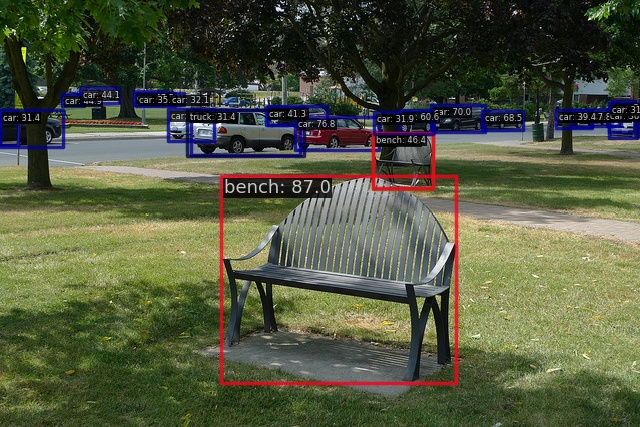

In [5]:
# Show the output image
from PIL import Image
Image.open('./output/vis/demo.jpg')

### Initialization

Each Inferencer must be initialized with a model. You can also choose the inference device during initialization.

#### Model Initialization

- To infer with MMDetection's pre-trained model, passing its name to the argument `model` can work. The weights will be automatically downloaded and loaded from OpenMMLab's model zoo.

In [6]:
inferencer = DetInferencer(model='rtmdet_tiny_8xb32-300e_coco')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet_tiny_8xb32-300e_coco/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



There is a very easy to list all model names in MMDetection.

In [7]:
# models is a list of model names, and them will print automatically
models = DetInferencer.list_models('mmdet')

03/28 00:40:54 - mmengine - INFO - model_name: mask-rcnn_r50_fpn_albu-1x_coco
model_name: atss_r50_fpn_1x_coco
model_name: atss_r101_fpn_1x_coco
model_name: autoassign_r50-caffe_fpn_1x_coco
model_name: boxinst_r50_fpn_ms-90k_coco
model_name: boxinst_r101_fpn_ms-90k_coco
model_name: faster-rcnn_r50_fpn_carafe_1x_coco
model_name: mask-rcnn_r50_fpn_carafe_1x_coco
model_name: cascade-rcnn_r50-caffe_fpn_1x_coco
model_name: cascade-rcnn_r50_fpn_1x_coco
model_name: cascade-rcnn_r50_fpn_20e_coco
model_name: cascade-rcnn_r101-caffe_fpn_1x_coco
model_name: cascade-rcnn_r101_fpn_1x_coco
model_name: cascade-rcnn_r101_fpn_20e_coco
model_name: cascade-rcnn_x101-32x4d_fpn_1x_coco
model_name: cascade-rcnn_x101-32x4d_fpn_20e_coco
model_name: cascade-rcnn_x101-64x4d_fpn_1x_coco
model_name: cascade-rcnn_x101_64x4d_fpn_20e_coco
model_name: cascade-mask-rcnn_r50-caffe_fpn_1x_coco
model_name: cascade-mask-rcnn_r50_fpn_1x_coco
model_name: cascade-mask-rcnn_r50_fpn_20e_coco
model_name: cascade-mask-rcnn_r101-

You can load another weight by passing its path/url to `weights`.

In [9]:
!mkdir ./checkpoints
!mim download mmdet --config rtmdet_tiny_8xb32-300e_coco --dest ./checkpoints

�訡�� � ᨭ⠪�� �������.


processing rtmdet_tiny_8xb32-300e_coco...
downloading ---------------------------------------- 0.0/54.9 MiB ? eta -:--:--
downloading --------------------------------- 0.2/54.9 MiB 3.4 MB/s eta 0:00:17
downloading --------------------------------- 0.4/54.9 MiB 4.2 MB/s eta 0:00:14
downloading --------------------------------- 0.6/54.9 MiB 4.3 MB/s eta 0:00:14
downloading --------------------------------- 0.8/54.9 MiB 4.4 MB/s eta 0:00:13
downloading  -------------------------------- 0.9/54.9 MiB 4.2 MB/s eta 0:00:14
downloading  -------------------------------- 1.2/54.9 MiB 4.7 MB/s eta 0:00:13
downloading  -------------------------------- 1.4/54.9 MiB 4.4 MB/s eta 0:00:13
downloading  -------------------------------- 1.5/54.9 MiB 4.4 MB/s eta 0:00:13
downloading - ------------------------------- 1.8/54.9 MiB 4.7 MB/s eta 0:00:12
downloading - ------------------------------- 1.9/54.9 MiB 4.4 MB/s eta 0:00:13
downloading - ------------------------------- 2.2/54.9 MiB 4.4 MB/s eta 0:00:1

In [10]:
# Setup a checkpoint file to load
checkpoint = './checkpoints/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth'

# Initialize the DetInferencer
inferencer = DetInferencer(model='rtmdet_tiny_8xb32-300e_coco', weights=checkpoint)

Loads checkpoint by local backend from path: ./checkpoints/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



- To load custom config and weight, you can pass the path to the config file to `model` and the path to the weight to `weights`.

In [13]:
# Choose to use a config
config_path = '../configs/rtmdet/rtmdet_tiny_8xb32-300e_coco.py'

# Setup a checkpoint file to load
checkpoint = './checkpoints/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth'

# Initialize the DetInferencer
inferencer = DetInferencer(model=config_path, weights=checkpoint)

Loads checkpoint by local backend from path: ./checkpoints/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



- By default, [MMEngine](https://github.com/open-mmlab/mmengine/) dumps config to the weight. If you have a weight trained on MMEngine, you can also pass the path to the weight file to `weights` without specifying `model`:

In [14]:
# It will raise an error if the config file cannot be found in the weight. Currently, within the MMDetection model repository, only the weights of ddq-detr-4scale_r50 can be loaded in this manner.
inferencer = DetInferencer(weights='https://download.openmmlab.com/mmdetection/v3.0/ddq/ddq-detr-4scale_r50_8xb2-12e_coco/ddq-detr-4scale_r50_8xb2-12e_coco_20230809_170711-42528127.pth')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/ddq/ddq-detr-4scale_r50_8xb2-12e_coco/ddq-detr-4scale_r50_8xb2-12e_coco_20230809_170711-42528127.pth


Downloading: "https://download.openmmlab.com/mmdetection/v3.0/ddq/ddq-detr-4scale_r50_8xb2-12e_coco/ddq-detr-4scale_r50_8xb2-12e_coco_20230809_170711-42528127.pth" to C:\Users\user/.cache\torch\hub\checkpoints\ddq-detr-4scale_r50_8xb2-12e_coco_20230809_170711-42528127.pth


The model and loaded state dict do not match exactly

unexpected key in source state_dict: decoder.aux_reg_branches.0.0.weight, decoder.aux_reg_branches.0.0.bias, decoder.aux_reg_branches.0.2.weight, decoder.aux_reg_branches.0.2.bias, decoder.aux_reg_branches.0.4.weight, decoder.aux_reg_branches.0.4.bias, decoder.aux_reg_branches.1.0.weight, decoder.aux_reg_branches.1.0.bias, decoder.aux_reg_branches.1.2.weight, decoder.aux_reg_branches.1.2.bias, decoder.aux_reg_branches.1.4.weight, decoder.aux_reg_branches.1.4.bias, decoder.aux_reg_branches.2.0.weight, decoder.aux_reg_branches.2.0.bias, decoder.aux_reg_branches.2.2.weight, decoder.aux_reg_branches.2.2.bias, decoder.aux_reg_branches.2.4.weight, decoder.aux_reg_branches.2.4.bias, decoder.aux_reg_branches.3.0.weight, decoder.aux_reg_branches.3.0.bias, decoder.aux_reg_branches.3.2.weight, decoder.aux_reg_branches.3.2.bias, decoder.aux_reg_branches.3.4.weight, decoder.aux_reg_branches.3.4.bias, decoder.aux_reg_branches.4.0.weight, decoder.

- Passing config file to `model` without specifying `weight` will result in a randomly initialized model.

### Device

Each Inferencer instance is bound to a device.
By default, the best device is automatically decided by [MMEngine](https://github.com/open-mmlab/mmengine/). You can also alter the device by specifying the `device` argument. For example, you can use the following code to create an Inferencer on GPU 0.

In [15]:
inferencer = DetInferencer(model='rtmdet_tiny_8xb32-300e_coco', device='cuda:0')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet_tiny_8xb32-300e_coco/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



To create an Inferencer on CPU:

In [16]:
inferencer = DetInferencer(model='rtmdet_tiny_8xb32-300e_coco', device='cpu')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet_tiny_8xb32-300e_coco/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



### Inference

Once the Inferencer is initialized, you can directly pass in the raw data to be inferred and get the inference results from return values.

#### Input

Input can be either of these types:

- str: Path/URL to the image.

In [18]:
inferencer = DetInferencer(model='rtmdet_tiny_8xb32-300e_coco', device='cuda:0')
inferencer('demo.jpg')

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet_tiny_8xb32-300e_coco/rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: data_preprocessor.mean, data_preprocessor.std



{'predictions': [{'labels': [13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    56,
    13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    7,
    2,
    2,
    2,
    2,
    0,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    56,
    56,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    60,
    2,
    13,
    7,
    2,
    7,
    2,
    2,
    16,
    2,
    7,
    2,
    2,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    7,
    2,
    7,
    2,
    2,
    7,
    7,
    2,
    2,
    60,
    2,
    2,
    13,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    7,
    2,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    13,
    7,
    7,
    7,
    2,
    7,
    2,
   

- array: Image in numpy array. It should be in BGR order.

In [19]:
import mmcv
array = mmcv.imread('demo.jpg')
inferencer(array)

{'predictions': [{'labels': [13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    56,
    13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    7,
    2,
    2,
    2,
    2,
    0,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    56,
    56,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    60,
    2,
    13,
    7,
    2,
    7,
    2,
    2,
    16,
    2,
    7,
    2,
    2,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    7,
    2,
    7,
    2,
    2,
    7,
    7,
    2,
    2,
    60,
    2,
    2,
    13,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    7,
    2,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    13,
    7,
    7,
    7,
    2,
    7,
    2,
   

- list: A list of basic types above. Each element in the list will be processed separately.

In [20]:
inferencer(['tests/data/color.jpg', 'tests/data/gray.jpg'])
# You can even mix the types
inferencer(['tests/data/color.jpg', array])

FileNotFoundError: [Errno 2] No such file or directory: 'tests/data/color.jpg'

- str: Path to the directory. All images in the directory will be processed.

In [ ]:
inferencer('tests/data/')

### Output

By default, each `Inferencer` returns the prediction results in a dictionary format.

- `visualization` contains the visualized predictions.

- `predictions` contains the predictions results in a json-serializable format. But it's an empty list by default unless `return_vis=True`.

In [21]:
# Show the structure of result dict
from rich.pretty import pprint

result = inferencer('demo.jpg')
pprint(result, max_length=4)

{
│   'predictions': [
│   │   {
│   │   │   'labels': [13, 2, 2, 2, ... +296],
│   │   │   'scores': [0.8701767921447754, 0.7677570581436157, 0.7431115508079529, 0.6996678709983826, ... +296],
│   │   │   'bboxes': [
│   │   │   │   [221.36782836914062, 176.12484741210938, 456.25537109375, 383.24688720703125],
│   │   │   │   [295.34637451171875, 117.18224334716797, 378.5791015625, 150.26736450195312],
│   │   │   │   [190.5690460205078, 109.70768737792969, 299.5196533203125, 155.03536987304688],
│   │   │   │   [431.3662109375, 104.97943115234375, 484.87799072265625, 131.94329833984375],
│   │   │   │   ... +296
│   │   │   ]
│   │   }
│   ],
│   'visualization': []
}

If you wish to get the raw outputs from the model, you can set `return_datasamples` to `True` to get the original `DataSample`, which will be stored in `predictions`.

In [22]:
result = inferencer('demo.jpg', return_datasamples=True)
pprint(result, max_length=4)

{
│   'predictions': [
│   │   <DetDataSample(
│   
│   META INFORMATION
│   img_path: 'demo.jpg'
│   scale_factor: (1.0, 1.0)
│   ori_shape: (427, 640)
│   pad_shape: (640, 640)
│   batch_input_shape: (640, 640)
│   img_shape: (640, 640)
│   
│   DATA FIELDS
│   pred_instances: <InstanceData(
│   │   │   
│   │   │   META INFORMATION
│   │   │   
│   │   │   DATA FIELDS
│   │   │   bboxes: tensor([[221.3678, 176.1248, 456.2554, 383.2469],
│   │   │   │   │   │   [295.3464, 117.1822, 378.5791, 150.2674],
│   │   │   │   │   │   [190.5690, 109.7077, 299.5197, 155.0354],
│   │   │   │   │   │   ...,
│   │   │   │   │   │   [609.3296,  92.1885, 639.2917, 135.4056],
│   │   │   │   │   │   [373.1335, 133.4483, 432.4998, 188.4483],
│   │   │   │   │   │   [141.4953,  94.1432, 184.4126, 107.8044]], device='cuda:0')
│   │   │   labels: tensor([13,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 56, 13,  2,  2,  2,
│   │   │   │   │   │    2,  2,  2,  2,  2,  2,  2,  7,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
│   │   │   │   │   │    2,  2,  2,  7,  2,  7,  2,  7,  2,  2,  2,  2,  0,  2,  7,  2,  2,  7,
│   │   │   │   │   │    2,  2, 56, 56,  2,  2,  2,  2,  2,  2,  7,  2,  2,  2,  2,  2,  2, 60,
│   │   │   │   │   │    2, 13,  7,  2,  7,  2,  2, 16,  2,  7,  2,  2, 13,  2,  2,  2,  2,  2,
│   │   │   │   │   │    7,  2,  7,  7,  2,  7,  2,  2,  7,  7,  2,  2, 60,  2,  2, 13, 13,  2,
│   │   │   │   │   │    2,  2,  2,  2,  7,  7,  2,  2,  7,  2,  2,  7,  2,  2,  2,  2,  2,  2,
│   │   │   │   │   │    7,  2,  7,  2, 13,  7,  7,  7,  2,  7,  2, 13,  0,  2,  2,  2, 17,  2,
│   │   │   │   │   │    2,  7, 28, 56,  7,  7,  2,  1,  2,  7, 13,  2,  2,  7,  2, 13,  2,  2,
│   │   │   │   │   │    7,  0,  2,  2,  7,  7, 58,  9,  7, 13, 57,  2,  2,  2,  7, 56,  2,  2,
│   │   │   │   │   │    3, 56, 13,  7,  7,  2, 13,  2,  0,  2,  0,  7, 16,  7,  7,  0,  7,  7,
│   │   │   │   │   │    2,  7,  7,  7,  7,  2, 13,  2,  2,  7,  2,  0,  5,  0,  0,  7,  7,  1,
│   │   │   │   │   │    2,  1,  7,  7,  2,  2,  1,  7,  2,  7,  2, 14, 13,  3, 13,  5,  7, 56,
│   │   │   │   │   │    7,  7,  3,  7,  0,  2,  2,  2, 13,  7,  2,  1, 13,  2, 13, 13,  2,  2,
│   │   │   │   │   │    7,  0,  3,  2,  3,  2,  2, 13,  7, 60,  7,  7, 56,  3,  0,  2, 13,  5,
│   │   │   │   │   │    0,  0, 60,  2,  7,  7,  7,  0,  7, 59,  7,  2,  2,  2,  2,  1,  7,  1,
│   │   │   │   │   │    2,  5,  7,  0,  0,  0,  7, 56,  0,  7,  3,  1], device='cuda:0')
│   │   │   scores: tensor([0.8702, 0.7678, 0.7431, 0.6997, 0.6848, 0.6240, 0.6100, 0.6064, 0.5570,
│   │   │   │   │   │   0.5525, 0.5016, 0.4782, 0.4749, 0.4725, 0.4637, 0.4492, 0.4412, 0.4127,
│   │   │   │   │   │   0.3941, 0.3656, 0.3528, 0.3440, 0.3214, 0.3185, 0.3142, 0.3141, 0.3123,
│   │   │   │   │   │   0.2987, 0.2897, 0.2763, 0.2757, 0.2732, 0.2701, 0.2659, 0.2569, 0.2534,
│   │   │   │   │   │   0.2482, 0.2349, 0.2307, 0.2259, 0.2257, 0.2250, 0.2240, 0.2233, 0.2198,
│   │   │   │   │   │   0.2139, 0.2102, 0.2054, 0.1990, 0.1974, 0.1970, 0.1909, 0.1907, 0.1869,
│   │   │   │   │   │   0.1867, 0.1827, 0.1814, 0.1796, 0.1791, 0.1761, 0.1760, 0.1743, 0.1739,
│   │   │   │   │   │   0.1726, 0.1714, 0.1712, 0.1708, 0.1693, 0.1691, 0.1650, 0.1650, 0.1625,
│   │   │   │   │   │   0.1622, 0.1621, 0.1610, 0.1574, 0.1566, 0.1525, 0.1480, 0.1476, 0.1475,
│   │   │   │   │   │   0.1472, 0.1462, 0.1441, 0.1438, 0.1420, 0.1411, 0.1408, 0.1400, 0.1382,
│   │   │   │   │   │   0.1381, 0.1372, 0.1362, 0.1352, 0.1291, 0.1283, 0.1280, 0.1211, 0.1206,
│   │   │   │   │   │   0.1195, 0.1144, 0.1141, 0.1140, 0.1136, 0.1135, 0.1130, 0.1112, 0.1107,
│   │   │   │   │   │   0.1085, 0.1069, 0.1068, 0.1064, 0.1063, 0.1063, 0.1050, 0.1044, 0.1044,
│   │   │   │   │   │   0.1043, 0.1040, 0.1019, 0.1010, 0.1006, 0.0993, 0.0989, 0.0985, 0.0984,
│   │   │   │   │   │   0.0982, 0.0981, 0.0976, 0.0965, 0.0965, 0.0962, 0.0961, 0.0958, 0.0955,
│   │   │   │   │   │   0.0954, 0.0944, 0.0944, 0.0942, 0.0931, 0.0923, 0.0922, 0.0921, 0.0917,
│   │   │

#### Dumping Results

Apart from obtaining predictions from the return value, you can also export the predictions/visualizations to files by setting `out_dir` and `no_save_pred`/`no_save_vis` arguments.

In [23]:
inferencer('demo.jpg', out_dir='outputs/', no_save_pred=False)

{'predictions': [{'labels': [13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    56,
    13,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    7,
    2,
    2,
    2,
    2,
    0,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    56,
    56,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    60,
    2,
    13,
    7,
    2,
    7,
    2,
    2,
    16,
    2,
    7,
    2,
    2,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    7,
    2,
    7,
    2,
    2,
    7,
    7,
    2,
    2,
    60,
    2,
    2,
    13,
    13,
    2,
    2,
    2,
    2,
    2,
    7,
    7,
    2,
    2,
    7,
    2,
    2,
    7,
    2,
    2,
    2,
    2,
    2,
    2,
    7,
    2,
    7,
    2,
    13,
    7,
    7,
    7,
    2,
    7,
    2,
   